# Tutorial 10: world models: Gaussian splats, a learned simulator, and planning inside it
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T10_world_models.ipynb)
Recap slides: [T10_world_models_recap.pdf](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T10_world_models_recap.pdf)

Plan for today (≈ 60 min):
1. Lecture recap: 3D from images (3DGS, VGGT), video and latent world models (Genie 3, Cosmos, V-JEPA 2), model-based RL and MPC, VLAs (10 min)
2. 2D Gaussian splatting: fit an image with differentiable Gaussians (15 min)
3. A toy environment and an action-conditioned next-frame predictor (10 min)
4. Imagined rollouts: how fast does the model drift from reality? (5 min)
5. Planning inside the learned model: random shooting and CEM (MPC) (10 min)
6. Compounding error: teacher forcing vs training on the model's own rollouts (10 min)
7. If time: from 3D Gaussians to 2D splats (the camera projection)

Runs on a laptop CPU in under 10 minutes. Cells marked ✏️ are for you to try.
On a Colab GPU, scale up the image size and Gaussian count in section 2 and the data / training steps in sections 3 and 6; the comments next to them say where.

In [1]:
import math, random, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
torch.manual_seed(0); random.seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"   # everything here is tiny; the CPU is faster than launching GPU kernels
T0 = time.time()

## 1. Lecture recap

A **world model** predicts what happens next given an action, $\;p_\theta(o_{t+1}\mid o_{\le t}, a_t)$. Three ways to build one (slide "World models: three paradigms"):

| paradigm | what is generated | examples |
|---|---|---|
| 3D scene | an explicit scene you render from any camera | 3D Gaussian splatting, VGGT, World Labs Marble |
| interactive video | the next frame, given the user's action | Genie 3 (DeepMind), NVIDIA Cosmos, GameNGen |
| latent | the next *embedding*, not pixels | V-JEPA 2 (Meta) |

**3D Gaussian splatting (3DGS).** A scene is a set of 3D Gaussians, each with mean $\mu_i$, covariance $\Sigma_i = R_i S_i S_i^\top R_i^\top$ (rotation × scale, so it stays positive semi-definite), opacity $o_i$ and color $c_i$. To render, each is projected to a 2D Gaussian on the image plane, $\Sigma_i' = J W \Sigma_i W^\top J^\top$ ($W$: camera rotation, $J$: Jacobian of the perspective projection), sorted by depth and **alpha-composited** front to back:
$$C(p) = \sum_i c_i\,\alpha_i(p)\prod_{j<i}\big(1-\alpha_j(p)\big),\qquad \alpha_i(p) = o_i\,\exp\!\big(-\tfrac12 (p-\mu_i')^\top \Sigma_i'^{-1}(p-\mu_i')\big).$$
Everything is differentiable, so the Gaussians are fit to a few hundred posed photos by gradient descent (minutes per scene), then rendered in real time.
**VGGT** (Visual Geometry Grounded Transformer, CVPR 2025) removes the per-scene optimization: one forward pass of a transformer over 1 to hundreds of images outputs the camera parameters, depth maps, 3D point maps and point tracks.

**Interactive video world models** are the video generators of Lecture 10b (latent flow-matching transformers) made *causal* and *action-conditioned*: frame $t+1$ is generated from the past frames and the user's action. Genie (DeepMind) learns *latent actions* from unlabeled video; Genie 3 (Aug 2025) generates playable 720p worlds in real time that stay consistent for minutes. NVIDIA Cosmos is a family of open "world foundation models" (video prediction, control-conditioned transfer, a reasoning VLM) for generating training data for robots and cars.
**Latent world models** skip pixels: V-JEPA 2 pretrains a video encoder by predicting masked latents, then trains an action-conditioned predictor on ≈ 60 hours of robot video and plans pick-and-place by CEM over action sequences in latent space, toward the embedding of a goal image. That is section 5 of today, in latents.

**Model-based RL** (slide "Types of RL algorithms"): learn the transition model $\hat s_{t+1} = f_\theta(s_t, a_t)$ from data, then use it to plan. **Model-predictive control (MPC):** at every step solve
$$a^*_{t:t+H} = \arg\min_{a_{t:t+H}} \sum_{k=1}^{H} c(\hat s_{t+k}),\qquad \hat s_{t+k} = f_\theta(\hat s_{t+k-1}, a_{t+k-1}),$$
execute only $a^*_t$, observe the real next state, replan. **Random shooting** samples $K$ action sequences and keeps the best. **CEM** (cross-entropy method) repeats: sample from a distribution, keep the $E$ lowest-cost *elites*, refit the distribution to them.

**Compounding error.** Behavior cloning with per-step error $\epsilon$ can be off by $O(\epsilon T^2)$ after $T$ steps, because each mistake puts the policy in states it never saw in training (slides "distributional shift", "Some analysis"). A world model rolled out on its own predictions has the same problem: it is trained on real frames (*teacher forcing*) and tested on its own, slightly wrong ones. The fixes are the same too: train on the model's own outputs (DAgger for imitation; multi-step / unrolled losses for models), add noise, and keep horizons short by replanning.

**Vision-language-action models (VLAs)** = behavior cloning with a VLM backbone: $\pi_\theta(a_{t:t+H}\mid \text{images}, \text{instruction})$. π0 / **π0.5** (Physical Intelligence) attach a flow-matching "action expert" that outputs action chunks; π0.5 is co-trained on many robots, web data and high-level subtask prediction to work in homes it has never seen. **Gemini Robotics** (DeepMind, Mar 2025) builds a VLA on Gemini 2.0. Like LLMs, they are then improved with RL or human corrections (DAgger-style).

## 2. 2D Gaussian splatting

We drop the third dimension and the camera, and keep the rest of 3DGS: fit a $64\times64$ photo with $N$ 2D Gaussians. Parameters per Gaussian: mean $\mu\in\mathbb{R}^2$ (pixels), log-scales $\log s\in\mathbb{R}^2$, rotation angle $\theta$, color logits (3), opacity logit. Covariance and its closed-form inverse ($2\times2$):
$$\Sigma = R(\theta)\,\mathrm{diag}(s_1^2, s_2^2)\,R(\theta)^\top,\qquad \Sigma = \begin{pmatrix} a & b\\ b & d\end{pmatrix},\quad \Sigma^{-1} = \frac{1}{ad-b^2}\begin{pmatrix} d & -b\\ -b & a\end{pmatrix}.$$

In [2]:
img = plt.imread(cbook.get_sample_data("grace_hopper.jpg"))      # ships with matplotlib, no download
S = 64                                                           # Colab GPU: S = 256
t = torch.tensor(img).float().permute(2, 0, 1)[None] / 255
h, w = t.shape[-2:]; c = min(h, w)
t = t[..., (h - c) // 2:(h - c) // 2 + c, (w - c) // 2:(w - c) // 2 + c]
target = F.interpolate(t, (S, S), mode="area")[0].permute(1, 2, 0)        # S, S, 3 in [0, 1]
ys, xs = torch.meshgrid(torch.arange(S) + 0.5, torch.arange(S) + 0.5, indexing="ij")
pix = torch.stack([xs, ys], -1).reshape(-1, 2)                            # P = S*S pixel centers (x, y)
print("target", tuple(target.shape), " pixels", pix.shape[0])

def covariance(log_scale, theta):
    # log_scale: (N, 2), theta: (N,)  ->  Sigma: (N, 2, 2)
    s = log_scale.exp()
    cos, sin = theta.cos(), theta.sin()
    R = torch.stack([torch.stack([cos, -sin], -1), torch.stack([sin, cos], -1)], -2)
    return R @ torch.diag_embed(s ** 2) @ R.transpose(-1, -2)

def gaussian_weights(points, mu, Sigma):
    # points: (P, 2), mu: (N, 2), Sigma: (N, 2, 2)  ->  exp(-0.5 d^T Sigma^-1 d): (P, N), peak value 1
    a, b, d = Sigma[:, 0, 0], Sigma[:, 0, 1], Sigma[:, 1, 1]
    dx = points[:, None, :] - mu[None]                                    # P, N, 2
    q = (d * dx[..., 0] ** 2 - 2 * b * dx[..., 0] * dx[..., 1] + a * dx[..., 1] ** 2) / (a * d - b * b)
    return torch.exp(-0.5 * q)

target (64, 64, 3)  pixels 4096


**Check:** `torch.distributions.MultivariateNormal` gives the normalized log-density; adding back the normalizer $\log(2\pi) + \tfrac12\log\det\Sigma$ gives our unnormalized weight.

In [3]:
mu_t, ls_t, th_t = torch.randn(5, 2) * 3, torch.randn(5, 2) * 0.5, torch.rand(5) * math.pi
Sig = covariance(ls_t, th_t)
pts = torch.randn(7, 2) * 3
ours = gaussian_weights(pts, mu_t, Sig)
mvn = torch.distributions.MultivariateNormal(mu_t, covariance_matrix=Sig)
ref = torch.exp(mvn.log_prob(pts[:, None, :]) + math.log(2 * math.pi) + 0.5 * torch.logdet(Sig))
print("max |ours - torch| =", (ours - ref).abs().max().item())
print("Sigma symmetric:", torch.allclose(Sig, Sig.transpose(-1, -2)), "  eigenvalues = s^2:",
      torch.allclose(torch.linalg.eigvalsh(Sig).sort(-1).values, (2 * ls_t).exp().sort(-1).values, atol=1e-5))

max |ours - torch| = 1.1920928955078125e-07
Sigma symmetric: True   eigenvalues = s^2: True


**Rasterization.** Each pixel composites the Gaussians in a fixed order (in 3DGS: sorted by depth). With $\alpha_{pi} = o_i\,g_i(p)$, the *transmittance* in front of Gaussian $i$ is $T_{pi}=\prod_{j<i}(1-\alpha_{pj})$, an exclusive cumulative product, and $C(p) = \sum_i T_{pi}\,\alpha_{pi}\,c_i$. The simpler alternative, **additive blending**, drops the occlusion term: $C(p) = \sum_i \alpha_{pi}\,c_i$.

In [4]:
def composite(alpha, colors):
    # alpha: (P, N) in [0, 1], front-to-back order; colors: (N, 3)  ->  (P, 3)
    T = torch.cumprod(torch.cat([torch.ones_like(alpha[:, :1]), 1 - alpha[:, :-1]], 1), 1)
    return (T * alpha) @ colors

def composite_loop(alpha, colors):
    # reference: the "over" operator, painted back to front, one Gaussian at a time
    out = torch.zeros(alpha.shape[0], 3)
    for i in reversed(range(alpha.shape[1])):
        out = alpha[:, i:i + 1] * colors[i] + (1 - alpha[:, i:i + 1]) * out
    return out

al, cols = torch.rand(100, 12), torch.rand(12, 3)
print("max |cumprod - loop| =", (composite(al, cols) - composite_loop(al, cols)).abs().max().item())

max |cumprod - loop| = 1.7881393432617188e-07


Now the renderer and the fit. Means are initialized on random pixels with the target color there; scales so that $N$ Gaussians of radius $S/\sqrt N$ tile the image. Loss: MSE; metric: **PSNR** $= -10\log_{10}\mathrm{MSE}$ (dB, images in $[0,1]$).

In [5]:
def render(p, blend="alpha"):
    Sigma = covariance(p["log_s"], p["theta"])
    alpha = (torch.sigmoid(p["opacity"]) * gaussian_weights(pix, p["mu"], Sigma)).clamp(max=0.99)
    colors = torch.sigmoid(p["color"])
    out = composite(alpha, colors) if blend == "alpha" else alpha @ colors
    return out.reshape(S, S, 3)

def init_gaussians(N, seed=0):
    g = torch.Generator().manual_seed(seed)
    idx = torch.randint(0, S * S, (N,), generator=g)
    p = dict(mu=pix[idx] + torch.rand(N, 2, generator=g) - 0.5,
             log_s=torch.full((N, 2), math.log(S / math.sqrt(N))),
             theta=torch.rand(N, generator=g) * math.pi,
             color=torch.logit(target.reshape(-1, 3)[idx].clamp(0.02, 0.98)),
             opacity=torch.zeros(N))
    return {k: v.clone().requires_grad_() for k, v in p.items()}

def psnr(x, y):
    return (-10 * torch.log10(F.mse_loss(x, y))).item()

def fit(N, steps=300, blend="alpha", lr=0.05):
    p = init_gaussians(N)
    opt = torch.optim.Adam(p.values(), lr=lr)
    curve = []
    for it in range(steps):
        out = render(p, blend)
        loss = F.mse_loss(out, target)
        opt.zero_grad(); loss.backward(); opt.step()
        if it % 10 == 0 or it == steps - 1:
            curve.append((it, -10 * math.log10(loss.item())))
    with torch.no_grad():
        out = render(p, blend)
    return p, out, curve

print("PSNR check:", psnr(target * 0 + 0.5, target), "vs", -10 * math.log10(F.mse_loss(target * 0 + 0.5, target).item()))

PSNR check: 9.759329795837402 vs 9.759329368099756


N =   16: PSNR  15.8 dB   (28.5s)


N =   64: PSNR  20.2 dB   (41.1s)


N =  256: PSNR  27.5 dB   (54.6s)


N =  512: PSNR  33.2 dB   (92.1s)


N =  256, additive blending: PSNR  22.9 dB


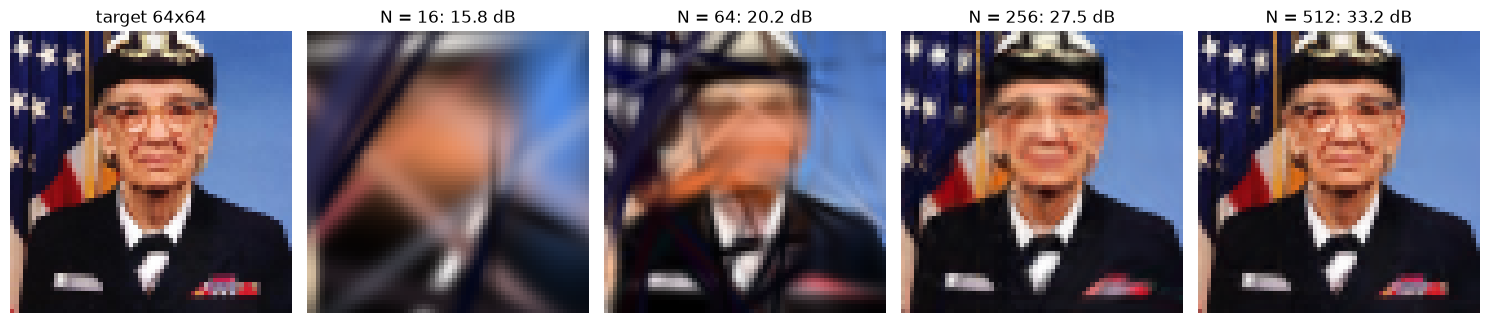

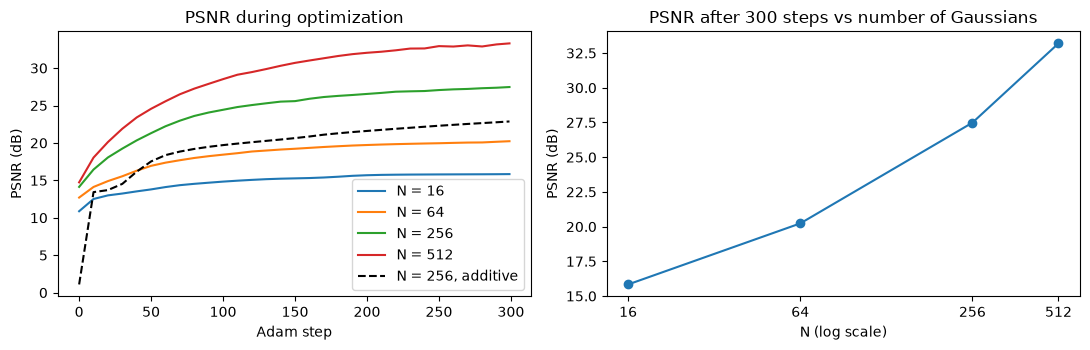

In [6]:
Ns = [16, 64, 256, 512]                  # Colab GPU: up to 4096 at S = 256
fits = {}
for N in Ns:
    t1 = time.time()
    fits[N] = fit(N)
    print(f"N = {N:4d}: PSNR {psnr(fits[N][1], target):5.1f} dB   ({time.time() - t1:.1f}s)")
_, out_add, curve_add = fit(256, blend="additive")
print(f"N =  256, additive blending: PSNR {psnr(out_add, target):5.1f} dB")

fig, axes = plt.subplots(1, len(Ns) + 1, figsize=(3 * (len(Ns) + 1), 3.2))
axes[0].imshow(target); axes[0].set_title("target 64x64")
for ax, N in zip(axes[1:], Ns):
    ax.imshow(fits[N][1].clamp(0, 1)); ax.set_title(f"N = {N}: {psnr(fits[N][1], target):.1f} dB")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for N in Ns:
    it, ps = zip(*fits[N][2]); axes[0].plot(it, ps, label=f"N = {N}")
it, ps = zip(*curve_add); axes[0].plot(it, ps, "k--", label="N = 256, additive")
axes[0].set(title="PSNR during optimization", xlabel="Adam step", ylabel="PSNR (dB)"); axes[0].legend()
axes[1].plot(Ns, [psnr(fits[N][1], target) for N in Ns], "o-")
axes[1].set(title="PSNR after 300 steps vs number of Gaussians", xlabel="N (log scale)", ylabel="PSNR (dB)", xscale="log")
axes[1].set_xticks(Ns, [str(n) for n in Ns]); axes[1].minorticks_off()
plt.tight_layout(); plt.show()

PSNR grows steadily with $N$: 15.8 dB with 16 Gaussians (a few blurry blobs), 20.2 dB with 64, 27.5 dB with 256 and 33.2 dB with 512 (one Gaussian per 8 pixels), and the $N=512$ curve is still rising at step 300. Additive blending with the same 256 Gaussians reaches 22.9 dB, 4.6 dB below alpha compositing: without occlusion every overlapping Gaussian adds its color, so a Gaussian cannot hide the ones behind it. It also starts near 1 dB, because the overlapping initial Gaussians sum to a saturated image.

✏️ Freeze the rotations (`theta.requires_grad_(False)` with $\theta=0$, axis-aligned Gaussians) or force isotropic scales. How many dB does each cost at $N=256$? Real 3DGS also **densifies** (clones/splits Gaussians where the gradient of $\mu$ is large) and **prunes** transparent ones; that is how it grows from a sparse point cloud to millions of Gaussians.

In [7]:
p256 = fits[256][0]
with torch.no_grad():
    Sig = covariance(p256["log_s"], p256["theta"])
    ev = torch.linalg.eigvalsh(Sig).sqrt()                  # std along the two principal axes
    aniso = (ev[:, 1] / ev[:, 0])
print(f"N = 256: median axis ratio {aniso.median():.1f}, 90th percentile {aniso.quantile(0.9):.1f}; "
      f"median opacity {torch.sigmoid(p256['opacity']).median():.2f}")

N = 256: median axis ratio 6.7, 90th percentile 44.5; median opacity 0.93


The fitted Gaussians are far from round: the median one is 6.7× longer than it is wide, and 10% are more than 44× (thin strokes along edges such as the flag stripes and the collar). Most are nearly opaque (median opacity 0.93), so the compositing order decides which one is visible. This is why 3DGS learns a full covariance (scale + rotation) and not only a radius.

## 3. A toy environment and an action-conditioned next-frame predictor

**Environment.** A ball in a $16\times16$ box with momentum. State $s=(x, y, v_x, v_y)$; 5 actions (none, +x, −x, +y, −y) push it:
$$v \leftarrow \mathrm{clip}(0.8\,v + 0.5\,d_a,\ \pm1.5),\qquad x \leftarrow x + v,\quad \text{reflect at the walls}.$$
The agent never sees $s$, only a $16\times16$ image with a Gaussian blob at $(x,y)$. One frame has no velocity, so the predictor gets **two frames** and the action:
$$\hat o_{t+1} = o_t + f_\theta(o_{t-1}, o_t, a_t)\qquad\text{(an MLP that predicts the change)}.$$
The environment is written in batched torch so the "true simulator" planner in section 5 can roll out many action sequences at once.

train frames (500, 41, 16, 16)  test frames (200, 41, 16, 16)


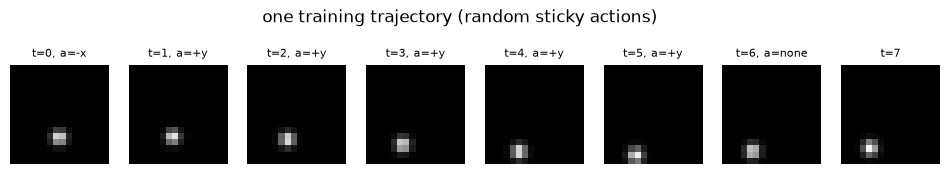

In [8]:
G, NA = 16, 5
LO, HI = 1.0, G - 1.0
DIRS = torch.tensor([[0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]], dtype=torch.float)
coords = torch.arange(G).float() + 0.5

def env_step(s, a):                       # s: (B, 4), a: (B,) long  ->  next state (B, 4)
    pos, vel = s[:, :2], s[:, 2:]
    vel = (0.8 * vel + 0.5 * DIRS[a]).clamp(-1.5, 1.5)
    pos = pos + vel
    lo, hi = pos < LO, pos > HI
    pos = torch.where(lo, 2 * LO - pos, pos); pos = torch.where(hi, 2 * HI - pos, pos)
    vel = torch.where(lo | hi, -vel, vel)
    return torch.cat([pos, vel], 1)

def render_ball(s, sigma=0.8):            # (B, 4) -> (B, G, G), row = y, column = x
    gx = torch.exp(-(coords[None] - s[:, 0:1]) ** 2 / (2 * sigma ** 2))
    gy = torch.exp(-(coords[None] - s[:, 1:2]) ** 2 / (2 * sigma ** 2))
    return gy[:, :, None] * gx[:, None, :]

def collect(n_traj, T, sticky=0.8, seed=0):
    # random policy that repeats its last action with prob. `sticky` (so the ball reaches high speeds)
    g = torch.Generator().manual_seed(seed)
    s = torch.cat([LO + torch.rand(n_traj, 2, generator=g) * (HI - LO), torch.randn(n_traj, 2, generator=g) * 0.5], 1)
    a = torch.randint(0, NA, (n_traj,), generator=g)
    states, actions = [s], []
    for _ in range(T):
        new = torch.randint(0, NA, (n_traj,), generator=g)
        a = torch.where(torch.rand(n_traj, generator=g) < sticky, a, new)
        actions.append(a); s = env_step(s, a); states.append(s)
    states, actions = torch.stack(states, 1), torch.stack(actions, 1)        # (n, T+1, 4), (n, T)
    frames = render_ball(states.reshape(-1, 4)).reshape(n_traj, T + 1, G, G)
    return states, actions, frames

S_tr, A_tr, O_tr = collect(500, 40, seed=0)       # 20k transitions. Colab GPU: 5000 trajectories
S_te, A_te, O_te = collect(200, 40, seed=1)
print("train frames", tuple(O_tr.shape), " test frames", tuple(O_te.shape))
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
names = ["none", "+x", "-x", "+y", "-y"]
for k, ax in enumerate(axes):
    ax.imshow(O_tr[0, k], cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"t={k}" + (f", a={names[A_tr[0, k]]}" if k < 7 else ""), fontsize=8)
plt.suptitle("one training trajectory (random sticky actions)", y=1.08); plt.show()

To score a plan we need the ball's position back from a (possibly blurry, predicted) frame. A plain center of mass is pulled toward the center by low-level noise spread over 256 pixels, so we keep only pixels above half of the frame's maximum, then take the weighted mean of their coordinates.

In [9]:
def centroid(frames):                     # (B, G, G) -> (B, 2) as (x, y)
    flat = frames.flatten(1)
    w = (flat - 0.5 * flat.max(1, keepdim=True).values).clamp(min=0)
    w = w / (w.sum(1, keepdim=True) + 1e-8)
    X, Y = coords.repeat(G), coords.repeat_interleave(G)
    return torch.stack([w @ X, w @ Y], 1)

err = (centroid(O_te[:, 5]) - S_te[:, 5, :2]).norm(dim=1)
print(f"centroid vs true position on real frames: mean {err.mean():.3f} px, max {err.max():.3f} px")

centroid vs true position on real frames: mean 0.036 px, max 0.072 px


In [10]:
class WorldModel(nn.Module):
    def __init__(self, hidden=512):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2 * G * G + NA, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, G * G))

    def forward(self, prev, cur, a):      # (B, G, G), (B, G, G), (B,) -> next frame (B, G, G)
        x = torch.cat([prev.flatten(1), cur.flatten(1), F.one_hot(a, NA).float()], 1)
        return cur + self.net(x).view(-1, G, G)

def sample_windows(O, A, k, bs, g):
    # random windows: frames o_{t-1} .. o_{t+k}, actions a_t .. a_{t+k-1}
    n, T = A.shape
    i = torch.randint(0, n, (bs,), generator=g); t = torch.randint(1, T - k + 1, (bs,), generator=g)
    frames = O[i[:, None], t[:, None] - 1 + torch.arange(k + 2)[None]]     # (bs, k+2, G, G)
    acts = A[i[:, None], t[:, None] + torch.arange(k)[None]]               # (bs, k)
    return frames, acts

def train_one_step(model, steps, bs=128, lr=1e-3, seed=0):
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr)
    for it in range(steps):
        frames, acts = sample_windows(O_tr, A_tr, 1, bs, g)
        pred = model(frames[:, 0], frames[:, 1], acts[:, 0])
        loss = F.mse_loss(pred, frames[:, 2])
        opt.zero_grad(); loss.backward(); opt.step()
        if it % 500 == 0 or it == steps - 1:
            print(f"step {it:4d}  train MSE {loss.item():.5f}")
    return model

torch.manual_seed(0)
t1 = time.time()
wm = train_one_step(WorldModel(), 2000)            # Colab GPU: 20000 steps
print(f"trained in {time.time() - t1:.0f}s")

step    0  train MSE 0.00481


step  500  train MSE 0.00139


step 1000  train MSE 0.00088


step 1500  train MSE 0.00074


step 1999  train MSE 0.00053
trained in 88s


**Check:** one-step test error against the "nothing moves" baseline $\hat o_{t+1} = o_t$, and the position error of the predicted ball.

In [11]:
with torch.no_grad():
    prev, cur = O_te[:, :-2].reshape(-1, G, G), O_te[:, 1:-1].reshape(-1, G, G)
    a, nxt = A_te[:, 1:].reshape(-1), O_te[:, 2:].reshape(-1, G, G)
    pred = wm(prev, cur, a)
    pos_true = S_te[:, 2:, :2].reshape(-1, 2)
print(f"one-step test MSE: model {F.mse_loss(pred, nxt).item():.5f}   copy-last-frame {F.mse_loss(cur, nxt).item():.5f}")
print(f"one-step position error: model {(centroid(pred) - pos_true).norm(dim=1).mean():.2f} px   "
      f"copy-last-frame {(centroid(cur) - pos_true).norm(dim=1).mean():.2f} px")

one-step test MSE: model 0.00074   copy-last-frame 0.00392
one-step position error: model 0.22 px   copy-last-frame 0.79 px


One step ahead the model beats copying the last frame by 5× in MSE (0.00074 vs 0.00392) and puts the ball within 0.22 px of the true position (copying: 0.79 px). From two frames it has inferred the velocity, the effect of the action, and the bounce.

✏️ Give the model only the current frame (`prev = cur`). The one-step error goes up a lot: which part of the state can it no longer infer?

## 4. Imagined rollouts

An **imagined** trajectory starts from two real frames and then feeds the model its own predictions:
$\hat o_{t+1} = f(o_{t-1}, o_t, a_t),\ \hat o_{t+2} = f(o_t, \hat o_{t+1}, a_{t+1}),\ \hat o_{t+3} = f(\hat o_{t+1}, \hat o_{t+2}, a_{t+2}), \dots$
This is exactly what Genie 3 does at 24 frames per second, and what a planner does when it evaluates an action sequence.

In [12]:
def rollout(model, prev, cur, actions):
    # prev, cur: (B, G, G) real frames; actions: (B, H)  ->  imagined frames (B, H, G, G)
    out = []
    for k in range(actions.shape[1]):
        nxt = model(prev, cur, actions[:, k])
        out.append(nxt)
        prev, cur = cur, nxt
    return torch.stack(out, 1)

with torch.no_grad():
    one = rollout(wm, O_te[:8, 0], O_te[:8, 1], A_te[:8, 1:2])[:, 0]
    print("horizon-1 rollout == one forward call:", (one - wm(O_te[:8, 0], O_te[:8, 1], A_te[:8, 1])).abs().max().item())

horizon-1 rollout == one forward call: 0.0


horizon  1: MSE 0.0008 (copy 0.0035)   position error 0.20 px (copy 0.77)
horizon  5: MSE 0.0060 (copy 0.0125)   position error 1.02 px (copy 3.62)
horizon 10: MSE 0.0135 (copy 0.0137)   position error 2.72 px (copy 5.32)
horizon 20: MSE 0.0627 (copy 0.0147)   position error 5.51 px (copy 6.67)


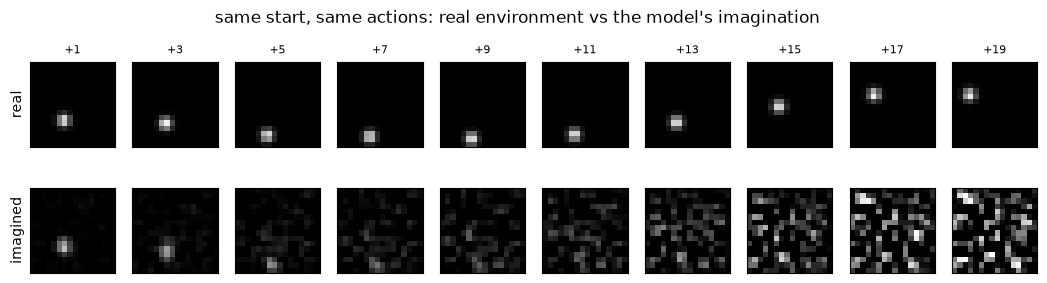

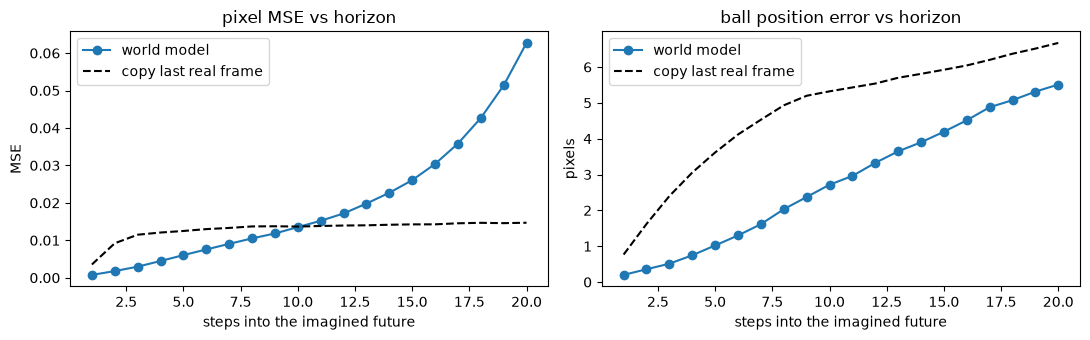

In [13]:
H = 20
@torch.no_grad()
def horizon_errors(model, H=H):
    imag = rollout(model, O_te[:, 0], O_te[:, 1], A_te[:, 1:1 + H])            # (n, H, G, G)
    real = O_te[:, 2:2 + H]
    mse = ((imag - real) ** 2).mean((0, 2, 3))
    pos = (centroid(imag.reshape(-1, G, G)).view(-1, H, 2) - S_te[:, 2:2 + H, :2]).norm(dim=-1).mean(0)
    return mse, pos, imag

mse_tf, pos_tf, imag = horizon_errors(wm)
copy_mse = ((O_te[:, 1:2] - O_te[:, 2:2 + H]) ** 2).mean((0, 2, 3))
copy_pos = (S_te[:, 1:2, :2] - S_te[:, 2:2 + H, :2]).norm(dim=-1).mean(0)
for k in [1, 5, 10, 20]:
    print(f"horizon {k:2d}: MSE {mse_tf[k-1]:.4f} (copy {copy_mse[k-1]:.4f})   position error {pos_tf[k-1]:.2f} px (copy {copy_pos[k-1]:.2f})")

fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for j, k in enumerate(range(0, H, 2)):
    axes[0, j].imshow(O_te[3, 2 + k], cmap="gray", vmin=0, vmax=1); axes[0, j].set_title(f"+{k+1}", fontsize=8)
    axes[1, j].imshow(imag[3, k], cmap="gray", vmin=0, vmax=1)
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("real"); axes[1, 0].set_ylabel("imagined")
plt.suptitle("same start, same actions: real environment vs the model's imagination", y=1.02); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
hs = range(1, H + 1)
axes[0].plot(hs, mse_tf, "o-", label="world model"); axes[0].plot(hs, copy_mse, "k--", label="copy last real frame")
axes[0].set(title="pixel MSE vs horizon", xlabel="steps into the imagined future", ylabel="MSE"); axes[0].legend()
axes[1].plot(hs, pos_tf, "o-", label="world model"); axes[1].plot(hs, copy_pos, "k--", label="copy last real frame")
axes[1].set(title="ball position error vs horizon", xlabel="steps into the imagined future", ylabel="pixels"); axes[1].legend()
plt.tight_layout(); plt.show()

The error grows with the horizon, and faster than linearly in pixel MSE: 0.0008, 0.0060, 0.0135, 0.0627 at horizons 1, 5, 10, 20. Beyond horizon 10 the imagined frame is *worse than repeating the last real frame* (0.0147 at horizon 20). The strip shows why: after ≈ 7 steps speckle noise appears and then fills the frame. The model is now fed inputs unlike anything in its training data, and it amplifies its own artifacts. The position error (0.20, 1.02, 2.72, 5.51 px) stays below the copy baseline, but 5.5 px in a 14-px box is close to useless. The usable horizon here is ≈ 5 steps (≈ 1 px). MPC replans after every step, so it needs mainly the first few steps to be right.

## 5. Planning inside the learned model (MPC)

**Task.** The ball starts at rest at a random position; a random goal position is given. After $T=15$ steps the ball must be **within 1 pixel of the goal**, so it has to arrive *and brake* (momentum). The cost of a plan is the summed distance to the goal over the planning horizon, $\sum_{k=1}^{H}\lVert \hat p_{t+k} - g\rVert$, where $\hat p$ is the centroid of the imagined frame. The reward is known here; only the dynamics are learned (Dreamer / TD-MPC learn the reward too).

**CEM** over $H=10$ discrete actions: keep a per-step categorical distribution $P\in\mathbb{R}^{H\times5}$, initialized uniform. Each iteration samples $K=200$ sequences, scores them, keeps the $E=20$ cheapest, and sets $P$ to the elites' action frequencies (mixed with 10% uniform so no action gets probability 0). One iteration is **random shooting**. MPC executes the first action of the best sequence, observes the real next frame, and replans.

In [14]:
def plan_cost(positions, goal):           # positions: (K, H, 2), goal: (2,)  ->  (K,)
    return (positions - goal).norm(dim=-1).sum(1)

def cem(predict_positions, goal, H=10, K=200, n_elite=20, iters=2, seed=0):
    g = torch.Generator().manual_seed(seed)
    probs = torch.full((H, NA), 1.0 / NA)
    for _ in range(iters):
        seqs = torch.multinomial(probs, K, replacement=True, generator=g).T      # (K, H)
        cost = plan_cost(predict_positions(seqs), goal)
        elites = seqs[cost.topk(n_elite, largest=False).indices]
        probs = 0.9 * F.one_hot(elites, NA).float().mean(0) + 0.1 / NA
    return elites[0, 0]                   # first action of the best sequence (elites are sorted by cost)

@torch.no_grad()
def true_positions(s):                    # planner that queries the real simulator
    def f(seqs):
        x, out = s.expand(seqs.shape[0], -1), []
        for k in range(seqs.shape[1]):
            x = env_step(x, seqs[:, k]); out.append(x[:, :2])
        return torch.stack(out, 1)
    return f

@torch.no_grad()
def model_positions(model, prev, cur):    # planner that only has the two latest frames and the learned model
    def f(seqs):
        K = seqs.shape[0]
        imag = rollout(model, prev[None].expand(K, -1, -1), cur[None].expand(K, -1, -1), seqs)
        return centroid(imag.reshape(-1, G, G)).view(K, -1, 2)
    return f

def run_episode(planner, seed, T=15, model=None, iters=2):
    g = torch.Generator().manual_seed(1000 + seed)
    s = torch.cat([LO + torch.rand(1, 2, generator=g) * (HI - LO), torch.zeros(1, 2)], 1)
    goal = LO + torch.rand(2, generator=g) * (HI - LO)
    prev = render_ball(s)[0]; path = [s[0, :2]]
    for t in range(T):
        cur = render_ball(s)[0]
        if planner == "random":
            a = torch.randint(0, NA, (), generator=g)
        elif planner == "true":
            a = cem(true_positions(s), goal, iters=iters, seed=seed * 100 + t)
        else:
            a = cem(model_positions(model, prev, cur), goal, iters=iters, seed=seed * 100 + t)
        prev = cur; s = env_step(s, a.view(1)); path.append(s[0, :2])
    d = (s[0, :2] - goal).norm().item()
    return d < 1.0, d, torch.stack(path), goal

**Check:** CEM with the *true* simulator must solve the task; a random policy must not.

In [15]:
N_EP = 30
def evaluate(planner, model=None, iters=2):
    t1 = time.time()
    res = [run_episode(planner, i, model=model, iters=iters) for i in range(N_EP)]
    succ = np.mean([r[0] for r in res]); dist = np.mean([r[1] for r in res])
    print(f"{planner:>6s}{'' if iters == 2 or planner == 'random' else f' (iters={iters})':12s}: success {succ:.2f}, "
          f"mean final distance {dist:.2f} px  ({time.time() - t1:.0f}s)")
    return res
res_true = evaluate("true")
res_rand = evaluate("random")

  true            : success 1.00, mean final distance 0.38 px  (2s)
random            : success 0.00, mean final distance 7.81 px  (0s)


 model            : success 0.90, mean final distance 0.57 px  (183s)


 model (iters=1)  : success 0.67, mean final distance 0.72 px  (61s)


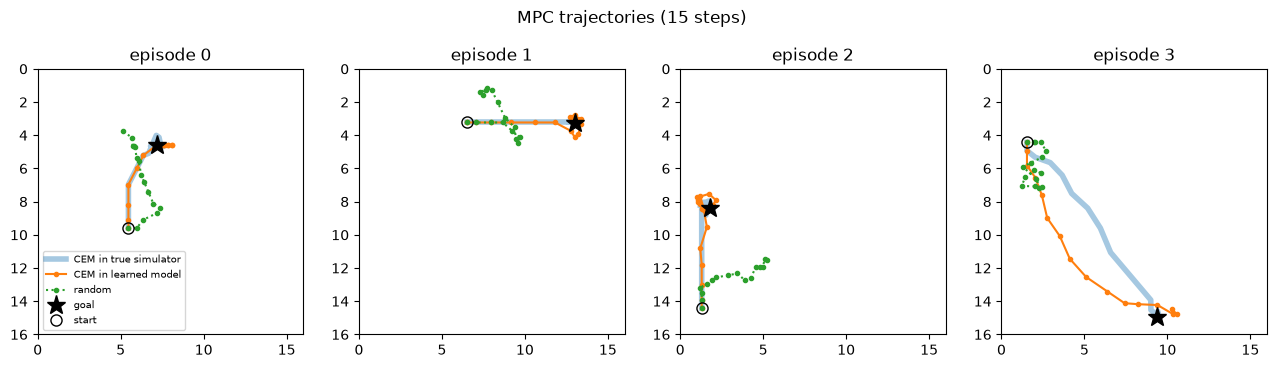

In [16]:
wm.eval()
res_model = evaluate("model", model=wm)
res_shoot = evaluate("model", model=wm, iters=1)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, i in zip(axes, range(4)):
    for res, lab, kw in [(res_true, "CEM in true simulator", dict(lw=4, alpha=0.4)), (res_model, "CEM in learned model", dict(marker=".")),
                         (res_rand, "random", dict(ls=":", marker="."))]:
        p = res[i][2]; ax.plot(p[:, 0], p[:, 1], label=lab, **kw)
    ax.plot(*res_true[i][3], "k*", ms=14, label="goal"); ax.plot(*res_true[i][2][0], "ko", mfc="none", ms=8, label="start")
    ax.set(xlim=(0, G), ylim=(G, 0), aspect="equal", title=f"episode {i}")
axes[0].legend(fontsize=7, loc="lower left")
plt.suptitle("MPC trajectories (15 steps)", y=1.02); plt.tight_layout(); plt.show()

CEM in the true simulator solves all 30 episodes (mean final distance 0.38 px); random actions solve none (7.81 px). With only the learned model and the two latest frames, the same planner (same horizon, same 2 × 200 samples) solves 90% (27/30, 0.57 px). This holds even though section 4 showed the imagination is ≈ 3 px off at the planning horizon $H=10$: MPC replans every step from a real frame, and the planner only needs the model to *rank* action sequences correctly, which the accurate first steps mostly decide. Random shooting (one CEM iteration) drops to 67% (0.72 px): refitting the sampling distribution to the elites matters when the ball has to arrive and stop. In the plots both planners reach the same goals; the learned-model planner (orange) sometimes takes a different route (episode 3) and overshoots slightly before stopping (episodes 0 and 2).

✏️ Plan with a *longer* horizon `H=20` in the learned model. Section 4 says the imagined positions are several pixels off by then: does success go up or down?

## 6. Compounding error: teacher forcing vs training on the model's own rollouts

Teacher forcing trains $f$ only on *real* inputs; at test time (section 4) its inputs are its own predictions, a distribution it never saw. This is the $O(\epsilon T^2)$ distribution-shift argument of behavior cloning, applied to a world model. Two standard fixes:
- **Unrolled (multi-step) loss**: roll the model out for $k$ steps from real frames, on its own predictions, and backpropagate the summed error through the whole rollout, $\;L = \frac1k\sum_{j=1}^{k}\lVert \hat o_{t+j} - o_{t+j}\rVert^2$. The model is now trained on its own input distribution (the DAgger idea, with the real future as the label).
- **Noise injection**: perturb the input frames during one-step training, so the model learns to map slightly wrong inputs back toward the data (cheap, no unrolling).

Same start for all three: the model of section 3 (2000 steps). We continue it with (a) 1000 more teacher-forcing steps, (b) 1000 steps with input noise $\sigma=0.01$, (c) only 200 steps with an 8-step unrolled loss (≈ the same number of forward passes as (a)).

In [17]:
def train_unrolled(model, steps, k=8, bs=128, lr=1e-3, seed=0, noise=0.0):
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr)
    for it in range(steps):
        frames, acts = sample_windows(O_tr, A_tr, k, bs, g)
        prev, cur = frames[:, 0], frames[:, 1]
        prev = prev + noise * torch.randn(prev.shape, generator=g); cur = cur + noise * torch.randn(cur.shape, generator=g)
        pred = rollout(model, prev, cur, acts)
        loss = F.mse_loss(pred, frames[:, 2:])
        opt.zero_grad(); loss.backward(); opt.step()
    return model

t1 = time.time()
models = {"(a) teacher forcing": train_unrolled(copy.deepcopy(wm).train(), 1000, k=1, seed=1),
          "(b) + input noise 0.01": train_unrolled(copy.deepcopy(wm).train(), 1000, k=1, noise=0.01, seed=1),
          "(c) 8-step unrolled": train_unrolled(copy.deepcopy(wm).train(), 200, k=8, seed=1)}
print(f"trained 3 models in {time.time() - t1:.0f}s")

trained 3 models in 78s


**Check:** with $k=1$ and no noise, `train_unrolled` is exactly teacher forcing: one step from the same start gives the same weights as `train_one_step`.

In [18]:
m1 = train_one_step(copy.deepcopy(wm), 1, seed=7)
m2 = train_unrolled(copy.deepcopy(wm), 1, k=1, seed=7)
print("max |weights difference| =", max((p - q).abs().max().item() for p, q in zip(m1.parameters(), m2.parameters())))

step    0  train MSE 0.00053
max |weights difference| = 0.0


(a) teacher forcing      MSE @1/5/10/20: 0.0006 0.0059 0.0138 0.0839   position error @1/5/10/20: 0.17 0.93 2.69 5.68


(b) + input noise 0.01   MSE @1/5/10/20: 0.0006 0.0054 0.0101 0.0177   position error @1/5/10/20: 0.18 0.94 2.44 4.55


(c) 8-step unrolled      MSE @1/5/10/20: 0.0010 0.0044 0.0070 0.0094   position error @1/5/10/20: 0.23 0.83 1.58 3.18


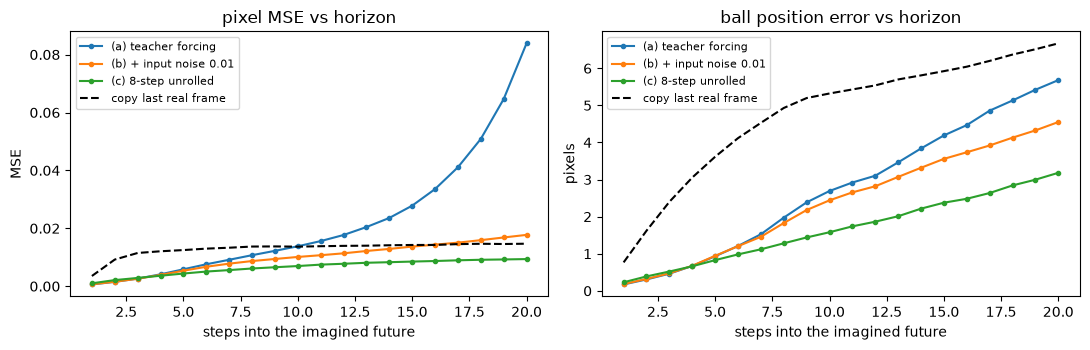

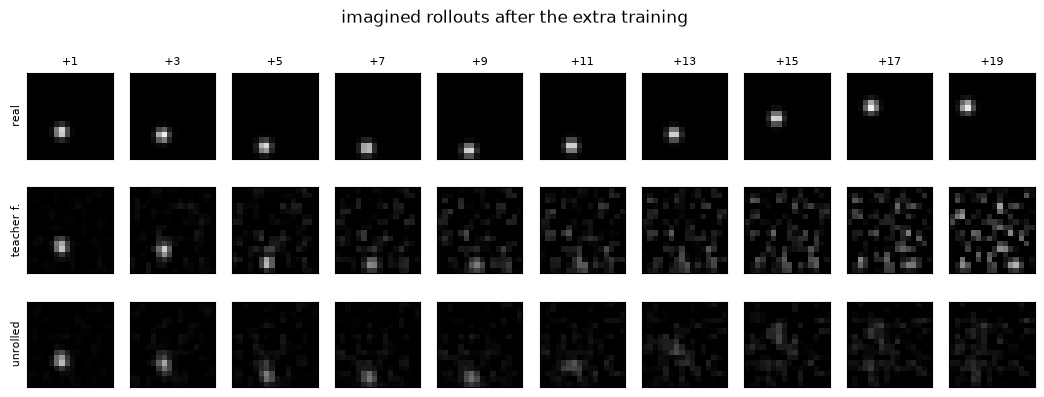

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
curves = {}
for name, m in models.items():
    mse, pos, _ = horizon_errors(m.eval())
    curves[name] = (mse, pos)
    axes[0].plot(hs, mse, "o-", ms=3, label=name); axes[1].plot(hs, pos, "o-", ms=3, label=name)
    print(f"{name:24s} MSE @1/5/10/20: " + " ".join(f"{mse[k-1]:.4f}" for k in [1, 5, 10, 20])
          + "   position error @1/5/10/20: " + " ".join(f"{pos[k-1]:.2f}" for k in [1, 5, 10, 20]))
axes[0].plot(hs, copy_mse, "k--", label="copy last real frame"); axes[1].plot(hs, copy_pos, "k--", label="copy last real frame")
axes[0].set(title="pixel MSE vs horizon", xlabel="steps into the imagined future", ylabel="MSE"); axes[0].legend(fontsize=8)
axes[1].set(title="ball position error vs horizon", xlabel="steps into the imagined future", ylabel="pixels"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

_, _, imag_u = horizon_errors(models["(c) 8-step unrolled"])
_, _, imag_t = horizon_errors(models["(a) teacher forcing"])
fig, axes = plt.subplots(3, 10, figsize=(13, 4.2))
for j, k in enumerate(range(0, H, 2)):
    for r, im in enumerate([O_te[3, 2 + k], imag_t[3, k], imag_u[3, k]]):
        axes[r, j].imshow(im, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"+{k+1}", fontsize=8)
for ax in axes.flat: ax.set_xticks([]); ax.set_yticks([])
for r, lab in enumerate(["real", "teacher f.", "unrolled"]): axes[r, 0].set_ylabel(lab, fontsize=8)
plt.suptitle("imagined rollouts after the extra training", y=1.02); plt.show()

- **Teacher forcing does not fix itself with more training.** (a) continued for 1000 steps improves the 1-step error (MSE 0.0006, 0.17 px) but the 20-step MSE gets *worse*: 0.0839, vs 0.0627 for the section 3 model.
- **The unrolled loss (c)** cuts the 20-step MSE 9× (0.0094) and the 20-step position error from 5.68 to 3.18 px, with only 200 updates. The price is a slightly worse 1-step prediction (0.0010 MSE, 0.23 px): the model now optimizes for the inputs it will see at test time, not only for real ones.
- **Noise injection (b)** is in between: no explosion (0.0177 at 20 steps) and 4.55 px.
- The strip shows *how* (c) achieves this: no speckle, but after ≈ 10 steps the blob fades and spreads. Under an MSE loss, when the model is unsure where the ball is, its best prediction is the average over the likely positions, a blur. It is uncertain instead of confidently wrong. Large video world models (Genie 3, Cosmos) are generative (diffusion / flow matching) so they can sample one sharp future instead of the blurry mean, and autoregressive video generators are trained on their own rollouts for the same reason as (c) (e.g. Self Forcing, 2025).

✏️ Plan with model (c): `evaluate("model", model=models["(c) 8-step unrolled"])` (about a minute). In our run (c) solved 93% and (a) 87% of the 30 episodes, a difference of 2 episodes, within noise: when MPC replans every step, long-horizon accuracy matters less than for open-loop imagination.

✏️ Unroll for $k=16$ instead of 8 (and 100 steps, same compute). Does the long-horizon error keep improving? What happens to the 1-step error?

## 7. If time: from 3D Gaussians to 2D splats

3DGS renders a 3D Gaussian $(\mu, \Sigma)$ in camera coordinates through the pinhole projection $\pi(x,y,z) = (f x/z,\ f y/z)$. A Gaussian pushed through a nonlinear map is not Gaussian, so 3DGS linearizes $\pi$ at the mean (EWA splatting): $\mu' = \pi(\mu)$ and
$$\Sigma' = J\,\Sigma\,J^\top,\qquad J = \frac{\partial \pi}{\partial (x,y,z)}\Big|_{\mu} = \begin{pmatrix} f/z & 0 & -f x/z^2 \\ 0 & f/z & -f y/z^2 \end{pmatrix}.$$
(With a camera rotation $W$, $\Sigma$ is first rotated to $W\Sigma W^\top$.) Check against Monte Carlo: sample points from the 3D Gaussian, project each one exactly, and measure the covariance of the 2D points.

In [20]:
def project_cov(mu, Sigma, f=50.0):
    x, y, z = mu
    J = torch.tensor([[f / z, 0, -f * x / z ** 2], [0, f / z, -f * y / z ** 2]])
    return J @ Sigma @ J.T

mu3 = torch.tensor([0.4, -0.3, 4.0])
A3 = torch.randn(3, 3) * 0.05
Sigma3 = A3 @ A3.T + 0.01 * torch.eye(3)
pts3 = torch.distributions.MultivariateNormal(mu3, Sigma3).sample((200_000,))
proj = 50.0 * pts3[:, :2] / pts3[:, 2:3]
print("EWA (linearized):\n", project_cov(mu3, Sigma3).numpy().round(3))
print("Monte Carlo:\n", torch.cov(proj.T).numpy().round(3))

EWA (linearized):
 [[ 2.974 -0.695]
 [-0.695  2.766]]
Monte Carlo:
 [[ 2.981 -0.681]
 [-0.681  2.782]]


✏️ Move the Gaussian closer to the camera (`z = 0.5`) or make it larger. When does the linearization break, and what does that look like in a real 3DGS render? (Hint: large Gaussians near the image border.)

## Summary
- **3D Gaussian splatting** represents a scene as anisotropic Gaussians ($\Sigma = RSS^\top R^\top$) rendered by front-to-back alpha compositing; everything is differentiable, so Adam fits them to images. In 2D: 15.8 → 33.2 dB from 16 to 512 Gaussians, and alpha compositing beats additive blending by 4.6 dB at $N=256$. VGGT predicts the geometry in one forward pass instead.
- **A world model** is an action-conditioned predictor $p(o_{t+1}\mid o_{\le t}, a_t)$, in pixels (Genie 3, Cosmos), in latents (V-JEPA 2) or as explicit 3D. Ours, an MLP on two $16\times16$ frames, is accurate to 0.2 px one step ahead.
- **Imagined rollouts drift**: the model is fed its own outputs, a distribution it never trained on. Errors compound, and past ≈ 10 steps our teacher-forced model is worse than copying the last frame.
- **MPC with CEM** inside the learned model reaches 90% of the true-simulator success (100%), because it replans from real observations and needs only a correct ranking of short plans.
- **Compounding error** is the $O(\epsilon T^2)$ distribution shift of behavior cloning. Training on the model's own rollouts (unrolled loss) cuts the 20-step error 9× at a small 1-step cost; noise injection helps partly. VLAs (π0.5, Gemini Robotics) face the same shift as policies and use the same fixes: recovery data, DAgger-style corrections, RL.

**Further reading:** DeepMind, *Genie 3: a new frontier for world models*, https://deepmind.google/discover/blog/genie-3-a-new-frontier-for-world-models/ ; NVIDIA Cosmos, https://www.nvidia.com/en-us/ai/cosmos/ ; Kerbl et al., *3D Gaussian Splatting for Real-Time Radiance Field Rendering*, https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/ ; Wang et al., *VGGT: Visual Geometry Grounded Transformer*, https://vgg-t.github.io/ ; Physical Intelligence, *π0.5*, https://www.physicalintelligence.company/blog/pi05 .

**Further watching:** Berkeley CS285 (Levine), lectures on model-based RL and planning (Lectures 10–12), https://rail.eecs.berkeley.edu/deeprlcourse/ .

In [21]:
print(f"total runtime: {(time.time() - T0) / 60:.1f} min")

total runtime: 11.6 min
